<a href="https://colab.research.google.com/github/DenisDrobyshev/universum/blob/master/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%966_%D0%9F%D1%80%D0%BE%D0%B5%D0%BA%D1%82%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%B0%D0%B2%D1%82%D0%BE%D1%8D%D0%BD%D0%BA%D0%BE%D0%B4%D0%B5%D1%80%D0%BE%D0%B2_%D0%B4%D0%BB%D1%8F_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F_%D0%BF%D1%80%D0%B8%D0%BA%D0%BB%D0%B0%D0%B4%D0%BD%D1%8B%D1%85_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №6. Проектирование автоэнкодеров для решения прикладных задач**


## **Задание №1. Реализуйте автоэнкодер для колоризации чёрно-белых изображений**



* **Чем больше объектов разных классов будет в исходном датасете, тем универсальнее будет работа обученной Вами модели**

> Например, если в Вашем датасете только кошки, то все объекты кроме кошек будут колоризоваться некорректно. Соответственно следует очень тщательно подойти к выбору датасета.

  * Для решения данной задачи может подойти датасет [CIFAR-100](https://www.kaggle.com/datasets/fedesoriano/cifar100), но его минус заключается в том, что разрешение изображений довольно низкое

* Хорошим вариантом будет использование датасета [ImageNet](https://paperswithcode.com/dataset/imagenet), но ввиду его объёмности, процесс обучения займет большое количество времени, поэтому Вы можете использовать одну из его [сокращенных версий](https://www.kaggle.com/datasets/ifigotin/imagenetmini-1000)



 **Конечный выбор датасета осуществляется по Вашему желанию (хорошо, если это будут Ваши датасеты), учитывая рекомендации приведенные выше.**


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from keras.models import Sequential, Model
from keras.layers import Conv2D, Conv2DTranspose, MaxPooling2D, UpSampling2D, Dense, Flatten, Reshape, Input, BatchNormalization, Dropout, LeakyReLU, Add
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger, TensorBoard
from keras.utils import to_categorical
from keras.datasets import cifar10, cifar100
from sklearn.model_selection import train_test_split
import tensorflow as tf
from google.colab import drive

In [ ]:
os.makedirs('models/autoencoders', exist_ok=True)
os.makedirs('logs/autoencoders', exist_ok=True)

In [ ]:
print('Загрузка датасета CIFAR-100...')

(trainX, trainy), (testX, testy) = cifar100.load_data()

print(f'Train: {trainX.shape}')
print(f'Test: {testX.shape}')

# Нормализация данных
trainX = trainX.astype('float32') / 255.0
testX = testX.astype('float32') / 255.0

Загрузка датасета CIFAR-100...
169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train: (50000, 32, 32, 3)
Test: (10000, 32, 32, 3)


In [ ]:
def rgb2lab(images):
    """Конвертация RGB в LAB цветовое пространство"""
    lab_images = []
    for img in images:
        img_lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        lab_images.append(img_lab)
    return np.array(lab_images)

def lab2rgb(images):
    """Конвертация LAB в RGB цветовое пространство"""
    rgb_images = []
    for img in images:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_LAB2RGB)
        rgb_images.append(img_rgb)
    return np.array(rgb_images)

print('Преобразование в LAB цветовое пространство...')
trainX_lab = rgb2lab(trainX)
testX_lab = rgb2lab(testX)

# L канал - светлота (черно-белое изображение)
# AB каналы - цветность
X_train_l = trainX_lab[:, :, :, 0:1] / 100.0  # Нормализация L канала
Y_train_ab = trainX_lab[:, :, :, 1:3] / 128.0  # Нормализация AB каналов

X_test_l = testX_lab[:, :, :, 0:1] / 100.0
Y_test_ab = testX_lab[:, :, :, 1:3] / 128.0

print(f'X_train_l shape: {X_train_l.shape}')
print(f'Y_train_ab shape: {Y_train_ab.shape}')

Преобразование в LAB цветовое пространство...
X_train_l shape: (50000, 32, 32, 1)
Y_train_ab shape: (50000, 32, 32, 2)


In [ ]:
def create_colorization_autoencoder(input_shape=(32, 32, 1)):
    # Encoder
    inputs = Input(shape=input_shape)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    # Decoder
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    # Выходной слой - 2 канала (AB)
    outputs = Conv2D(2, (3, 3), activation='tanh', padding='same')(x)

    model = Model(inputs, outputs)
    return model

model_colorization = create_colorization_autoencoder()
model_colorization.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 64)     │             

 Total params: 1,536,610 (5.86 MB)

 Trainable params: 1,534,370 (5.85 MB)

 Non-trainable params: 2,240 (8.75 KB)

In [ ]:
model_colorization.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

callbacks_color = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath='models/autoencoders/colorization_best.h5',
                    monitor='val_loss', save_best_only=True, mode='min', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    CSVLogger('models/autoencoders/colorization_history.csv', append=False),
    TensorBoard(log_dir='logs/autoencoders/colorization', histogram_freq=1)
]

print('Обучение модели колоризации...')
history_color = model_colorization.fit(
    X_train_l, Y_train_ab,
    epochs=75,
    batch_size=8,
    validation_split=0.2,
    callbacks=callbacks_color,
    verbose=1
)

Обучение модели колоризации...
Epoch 1/75
4999/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0218
Epoch 1: val_loss improved from None to 0.01926, saving model to models/autoencoders/colorization_best.h5



Epoch 1: finished saving model to models/autoencoders/colorization_best.h5
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 53s 8ms/step - loss: 0.0175 - val_loss: 0.0193 - learning_rate: 0.0010
Epoch 2/75
4999/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0155
Epoch 2: val_loss improved from 0.01926 to 0.01486, saving model to models/autoencoders/colorization_best.h5



Epoch 2: finished saving model to models/autoencoders/colorization_best.h5
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 38s 8ms/step - loss: 0.0152 - val_loss: 0.0149 - learning_rate: 0.0010
Epoch 3/75
4998/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0144
Epoch 3: val_loss improved from 0.01486 to 0.01405, saving model to models/autoencoders/colorization_best.h5



Epoch 3: finished saving model to models/autoencoders/colorization_best.h5
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 37s 7ms/step - loss: 0.0143 - val_loss: 0.0140 - learning_rate: 0.0010
Epoch 4/75
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0137
Epoch 4: val_loss did not improve from 0.01405
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 37s 7ms/step - loss: 0.0138 - val_loss: 0.0146 - learning_rate: 0.0010
Epoch 5/75
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0134
Epoch 5: val_loss improved from 0.01405 to 0.01379, saving model to models/autoencoders/colorization_best.h5



Epoch 5: finished saving model to models/autoencoders/colorization_best.h5
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - loss: 0.0135 - val_loss: 0.0138 - learning_rate: 0.0010
Epoch 6/75
4995/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0131
Epoch 6: val_loss did not improve from 0.01379
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 38s 8ms/step - loss: 0.0132 - val_loss: 0.0152 - learning_rate: 0.0010
Epoch 7/75
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0128
Epoch 7: val_loss did not improve from 0.01379
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 39s 8ms/step - loss: 0.0128 - val_loss: 0.0140 - learning_rate: 0.0010
Epoch 8/75
4998/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0126
Epoch 8: val_loss did not improve from 0.01379
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 39s 8ms/step - loss: 0.0125 - val_loss: 0.0153 - learning_rate: 0.0010
Epoch 9/75
4998/5000 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0121
Epoch 9: val_loss did not improve from 0.01379
5000/5000 ━━━━━━━━━━━━━━━━━━━━ 38s 8ms/step - loss: 

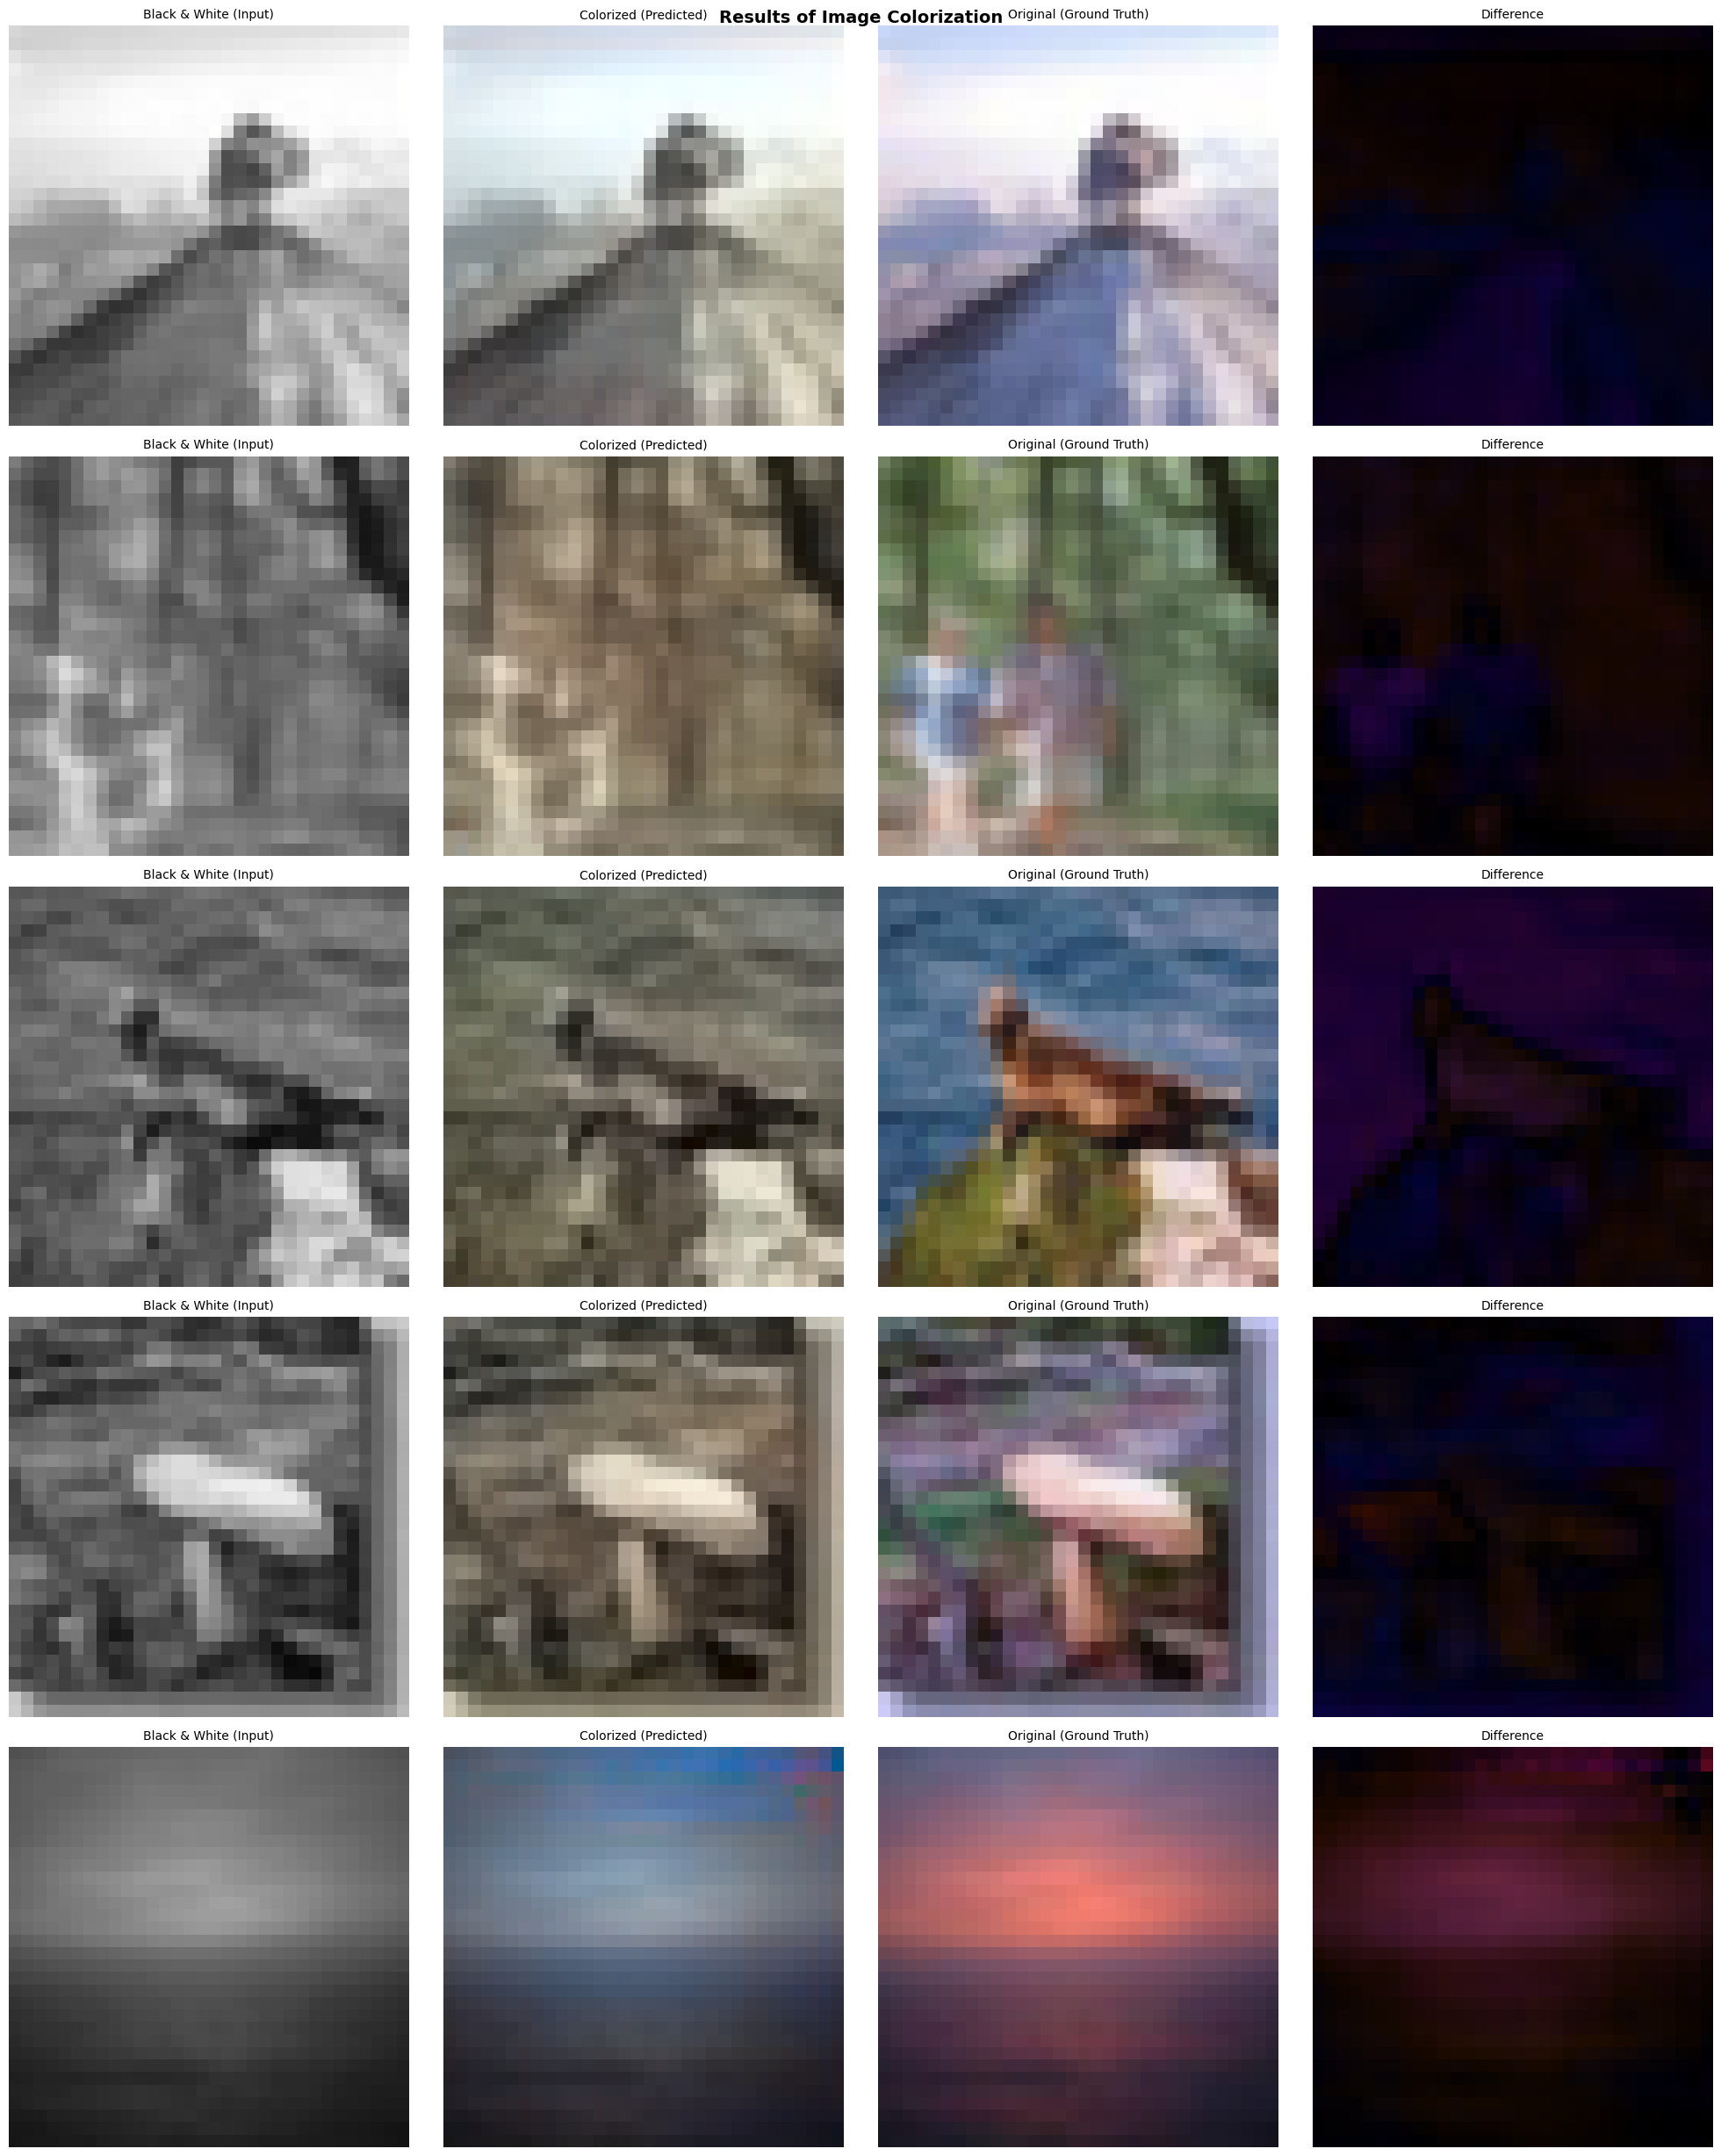

In [ ]:
def visualize_colorization(model, X_l, Y_ab, original_rgb, n_samples=5):
    """Визуализация результатов колоризации"""

    # Предсказание AB каналов
    predicted_ab = model.predict(X_l[:n_samples], verbose=0)

    fig, axes = plt.subplots(n_samples, 4, figsize=(20, 5 * n_samples))

    if n_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(n_samples):
        # Черно-белое изображение (L канал)
        l_channel = X_l[i] * 100
        gray_img = np.concatenate([l_channel, np.zeros((32, 32, 2))], axis=-1)
        gray_rgb = cv2.cvtColor(gray_img.astype('float32'), cv2.COLOR_LAB2RGB)

        axes[i, 0].imshow(gray_rgb)
        axes[i, 0].set_title('Black & White (Input)', fontsize=10)
        axes[i, 0].axis('off')

        # Предсказанное цветное
        predicted_lab = np.concatenate([X_l[i] * 100, predicted_ab[i] * 128], axis=-1)
        predicted_rgb = cv2.cvtColor(predicted_lab.astype('float32'), cv2.COLOR_LAB2RGB)

        axes[i, 1].imshow(predicted_rgb)
        axes[i, 1].set_title('Colorized (Predicted)', fontsize=10)
        axes[i, 1].axis('off')

        # Оригинальное цветное
        axes[i, 2].imshow(original_rgb[i])
        axes[i, 2].set_title('Original (Ground Truth)', fontsize=10)
        axes[i, 2].axis('off')

        # Разница
        diff = np.abs(original_rgb[i] - predicted_rgb)
        axes[i, 3].imshow(diff)
        axes[i, 3].set_title('Difference', fontsize=10)
        axes[i, 3].axis('off')

    plt.suptitle('Results of Image Colorization', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_colorization(model_colorization, X_test_l, Y_test_ab, testX, n_samples=5)

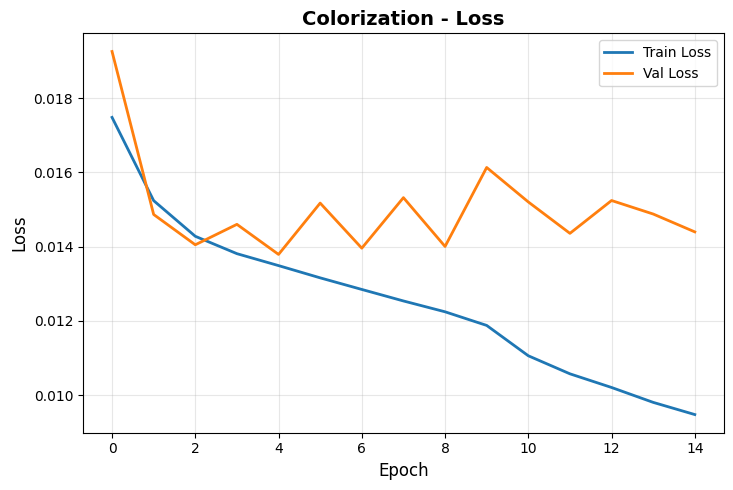

Final Train Loss: 0.0095
Final Val Loss: 0.0144


In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_color.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history_color.history['val_loss'], label='Val Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Colorization - Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final Train Loss: {history_color.history["loss"][-1]:.4f}')
print(f'Final Val Loss: {history_color.history["val_loss"][-1]:.4f}')

## **Задание №2. Реализуйте автоэнкодер для удаления шума на однотипных изображениях**



1.  Подберите датасет, состоящий из однотипных изображений, которые в реальной жизни часто подвержены зашумлению, например спутниковые снимки, ночные фотографии и т.д.

2.  Затем примените к ним операцию зашумления и обучите модель. Также учитывайте тип шума, который Вы применяете. Он должен быть приближен к естественному.

Хороший пример реализации подобной задачи: https://www.kaggle.com/code/michalbrezk/denoise-images-using-autoencoders-tf-keras

In [ ]:
print('Загрузка датасета CIFAR-10 для удаления шума...')

(trainX_denoise, trainy_denoise), (testX_denoise, testy_denoise) = cifar10.load_data()

# Нормализация
trainX_denoise = trainX_denoise.astype('float32') / 255.0
testX_denoise = testX_denoise.astype('float32') / 255.0

print(f'Train: {trainX_denoise.shape}')
print(f'Test: {testX_denoise.shape}')

Загрузка датасета CIFAR-10 для удаления шума...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train: (50000, 32, 32, 3)
Test: (10000, 32, 32, 3)


Добавление шума к изображениям...


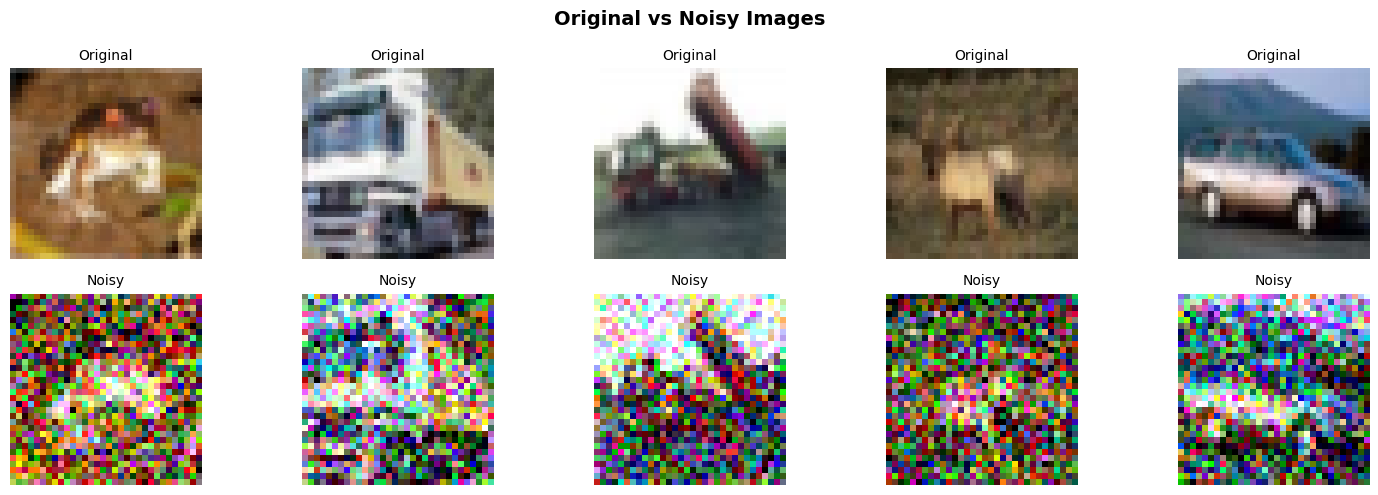

In [ ]:
def add_noise(images, noise_factor=0.3):
    """Добавление гауссовского шума к изображениям"""
    noisy_images = images + noise_factor * np.random.randn(*images.shape)
    noisy_images = np.clip(noisy_images, 0, 1)
    return noisy_images

print('Добавление шума к изображениям...')
X_train_noisy = add_noise(trainX_denoise, noise_factor=0.3)
X_test_noisy = add_noise(testX_denoise, noise_factor=0.3)

# Визуализация зашумленных изображений (ИСПРАВЛЕНО)
plt.figure(figsize=(15, 5))

for i in range(5):  # Показываем 5 изображений (10 подплотов всего)
    plt.subplot(2, 5, i+1)
    plt.imshow(trainX_denoise[i])
    plt.title('Original', fontsize=10)
    plt.axis('off')

    plt.subplot(2, 5, i+6)
    plt.imshow(X_train_noisy[i])
    plt.title('Noisy', fontsize=10)
    plt.axis('off')

plt.suptitle('Original vs Noisy Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
def create_denoising_autoencoder(input_shape=(32, 32, 3)):
    # Encoder
    inputs = Input(shape=input_shape)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    # Decoder
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2))(x)

    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    outputs = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    model = Model(inputs, outputs)
    return model

model_denoising = create_denoising_autoencoder()
model_denoising.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 761,667 (2.91 MB)

 Trainable params: 760,323 (2.90 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [ ]:
model_denoising.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse'
)

callbacks_denoise = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath='models/autoencoders/denoising_best.h5',
                    monitor='val_loss', save_best_only=True, mode='min', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    CSVLogger('models/autoencoders/denoising_history.csv', append=False),
    TensorBoard(log_dir='logs/autoencoders/denoising', histogram_freq=1)
]

print('Обучение модели удаления шума...')
history_denoise = model_denoising.fit(
    X_train_noisy, trainX_denoise,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks_denoise,
    verbose=1
)

Обучение модели удаления шума...
Epoch 1/50
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0134
Epoch 1: val_loss improved from None to 0.00765, saving model to models/autoencoders/denoising_best.h5



Epoch 1: finished saving model to models/autoencoders/denoising_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - loss: 0.0092 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0070
Epoch 2: val_loss improved from 0.00765 to 0.00705, saving model to models/autoencoders/denoising_best.h5



Epoch 2: finished saving model to models/autoencoders/denoising_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.0069 - val_loss: 0.0071 - learning_rate: 0.0010
Epoch 3/50
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0067
Epoch 3: val_loss improved from 0.00705 to 0.00669, saving model to models/autoencoders/denoising_best.h5



Epoch 3: finished saving model to models/autoencoders/denoising_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - loss: 0.0066 - val_loss: 0.0067 - learning_rate: 0.0010
Epoch 4/50
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0064
Epoch 4: val_loss improved from 0.00669 to 0.00621, saving model to models/autoencoders/denoising_best.h5



Epoch 4: finished saving model to models/autoencoders/denoising_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0064 - val_loss: 0.0062 - learning_rate: 0.0010
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0063
Epoch 5: val_loss improved from 0.00621 to 0.00617, saving model to models/autoencoders/denoising_best.h5


...


Epoch 30: finished saving model to models/autoencoders/denoising_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0053 - val_loss: 0.0054 - learning_rate: 6.2500e-05
Epoch 31/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0053
Epoch 31: val_loss did not improve from 0.00543
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0053 - val_loss: 0.0054 - learning_rate: 6.2500e-05
Epoch 32/50
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0053
Epoch 32: val_loss improved from 0.00543 to 0.00543, saving model to models/autoencoders/denoising_best.h5



Epoch 32: finished saving model to models/autoencoders/denoising_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0053 - val_loss: 0.0054 - learning_rate: 6.2500e-05
Epoch 33/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0053
Epoch 33: val_loss did not improve from 0.00543
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.0053 - val_loss: 0.0054 - learning_rate: 6.2500e-05
Epoch 34/50
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0053
Epoch 34: val_loss did not improve from 0.00543

Epoch 34: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0053 - val_loss: 0.0054 - learning_rate: 6.2500e-05
Epoch 35/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0053
Epoch 35: val_loss improved from 0.00543 to 0.00543, saving model to models/autoencoders/denoising_best.h5



Epoch 35: finished saving model to models/autoencoders/denoising_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - loss: 0.0053 - val_loss: 0.0054 - learning_rate: 3.1250e-05
Epoch 36/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0052
Epoch 36: val_loss did not improve from 0.00543
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0052 - val_loss: 0.0054 - learning_rate: 3.1250e-05
Epoch 37/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0052
Epoch 37: val_loss did not improve from 0.00543
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0052 - val_loss: 0.0054 - learning_rate: 3.1250e-05
Epoch 38/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0052
Epoch 38: val_loss did not improve from 0.00543
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0052 - val_loss: 0.0054 - learning_rate: 3.1250e-05
Epoch 39/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0052
Epoch 39: val_loss did not improve from 0.00543

Epoch 39: ReduceLROnPlateau reducing 


Epoch 41: finished saving model to models/autoencoders/denoising_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0052 - val_loss: 0.0054 - learning_rate: 1.5625e-05
Epoch 42/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0052
Epoch 42: val_loss did not improve from 0.00543
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0052 - val_loss: 0.0054 - learning_rate: 1.5625e-05
Epoch 43/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0052
Epoch 43: val_loss did not improve from 0.00543
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0052 - val_loss: 0.0054 - learning_rate: 1.5625e-05
Epoch 44/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0052
Epoch 44: val_loss did not improve from 0.00543

Epoch 44: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0052 - val_loss: 0.0054 - learning_rate: 1.5625e-05
Epoch 45/50
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0052
Epoch 45


Epoch 46: finished saving model to models/autoencoders/denoising_best.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - loss: 0.0052 - val_loss: 0.0054 - learning_rate: 7.8125e-06
Epoch 47/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0052
Epoch 47: val_loss did not improve from 0.00543
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0052 - val_loss: 0.0054 - learning_rate: 7.8125e-06
Epoch 48/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0052
Epoch 48: val_loss did not improve from 0.00543
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0052 - val_loss: 0.0054 - learning_rate: 7.8125e-06
Epoch 49/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0052
Epoch 49: val_loss did not improve from 0.00543

Epoch 49: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - loss: 0.0052 - val_loss: 0.0054 - learning_rate: 7.8125e-06
Epoch 50/50
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0052
Epoch 50

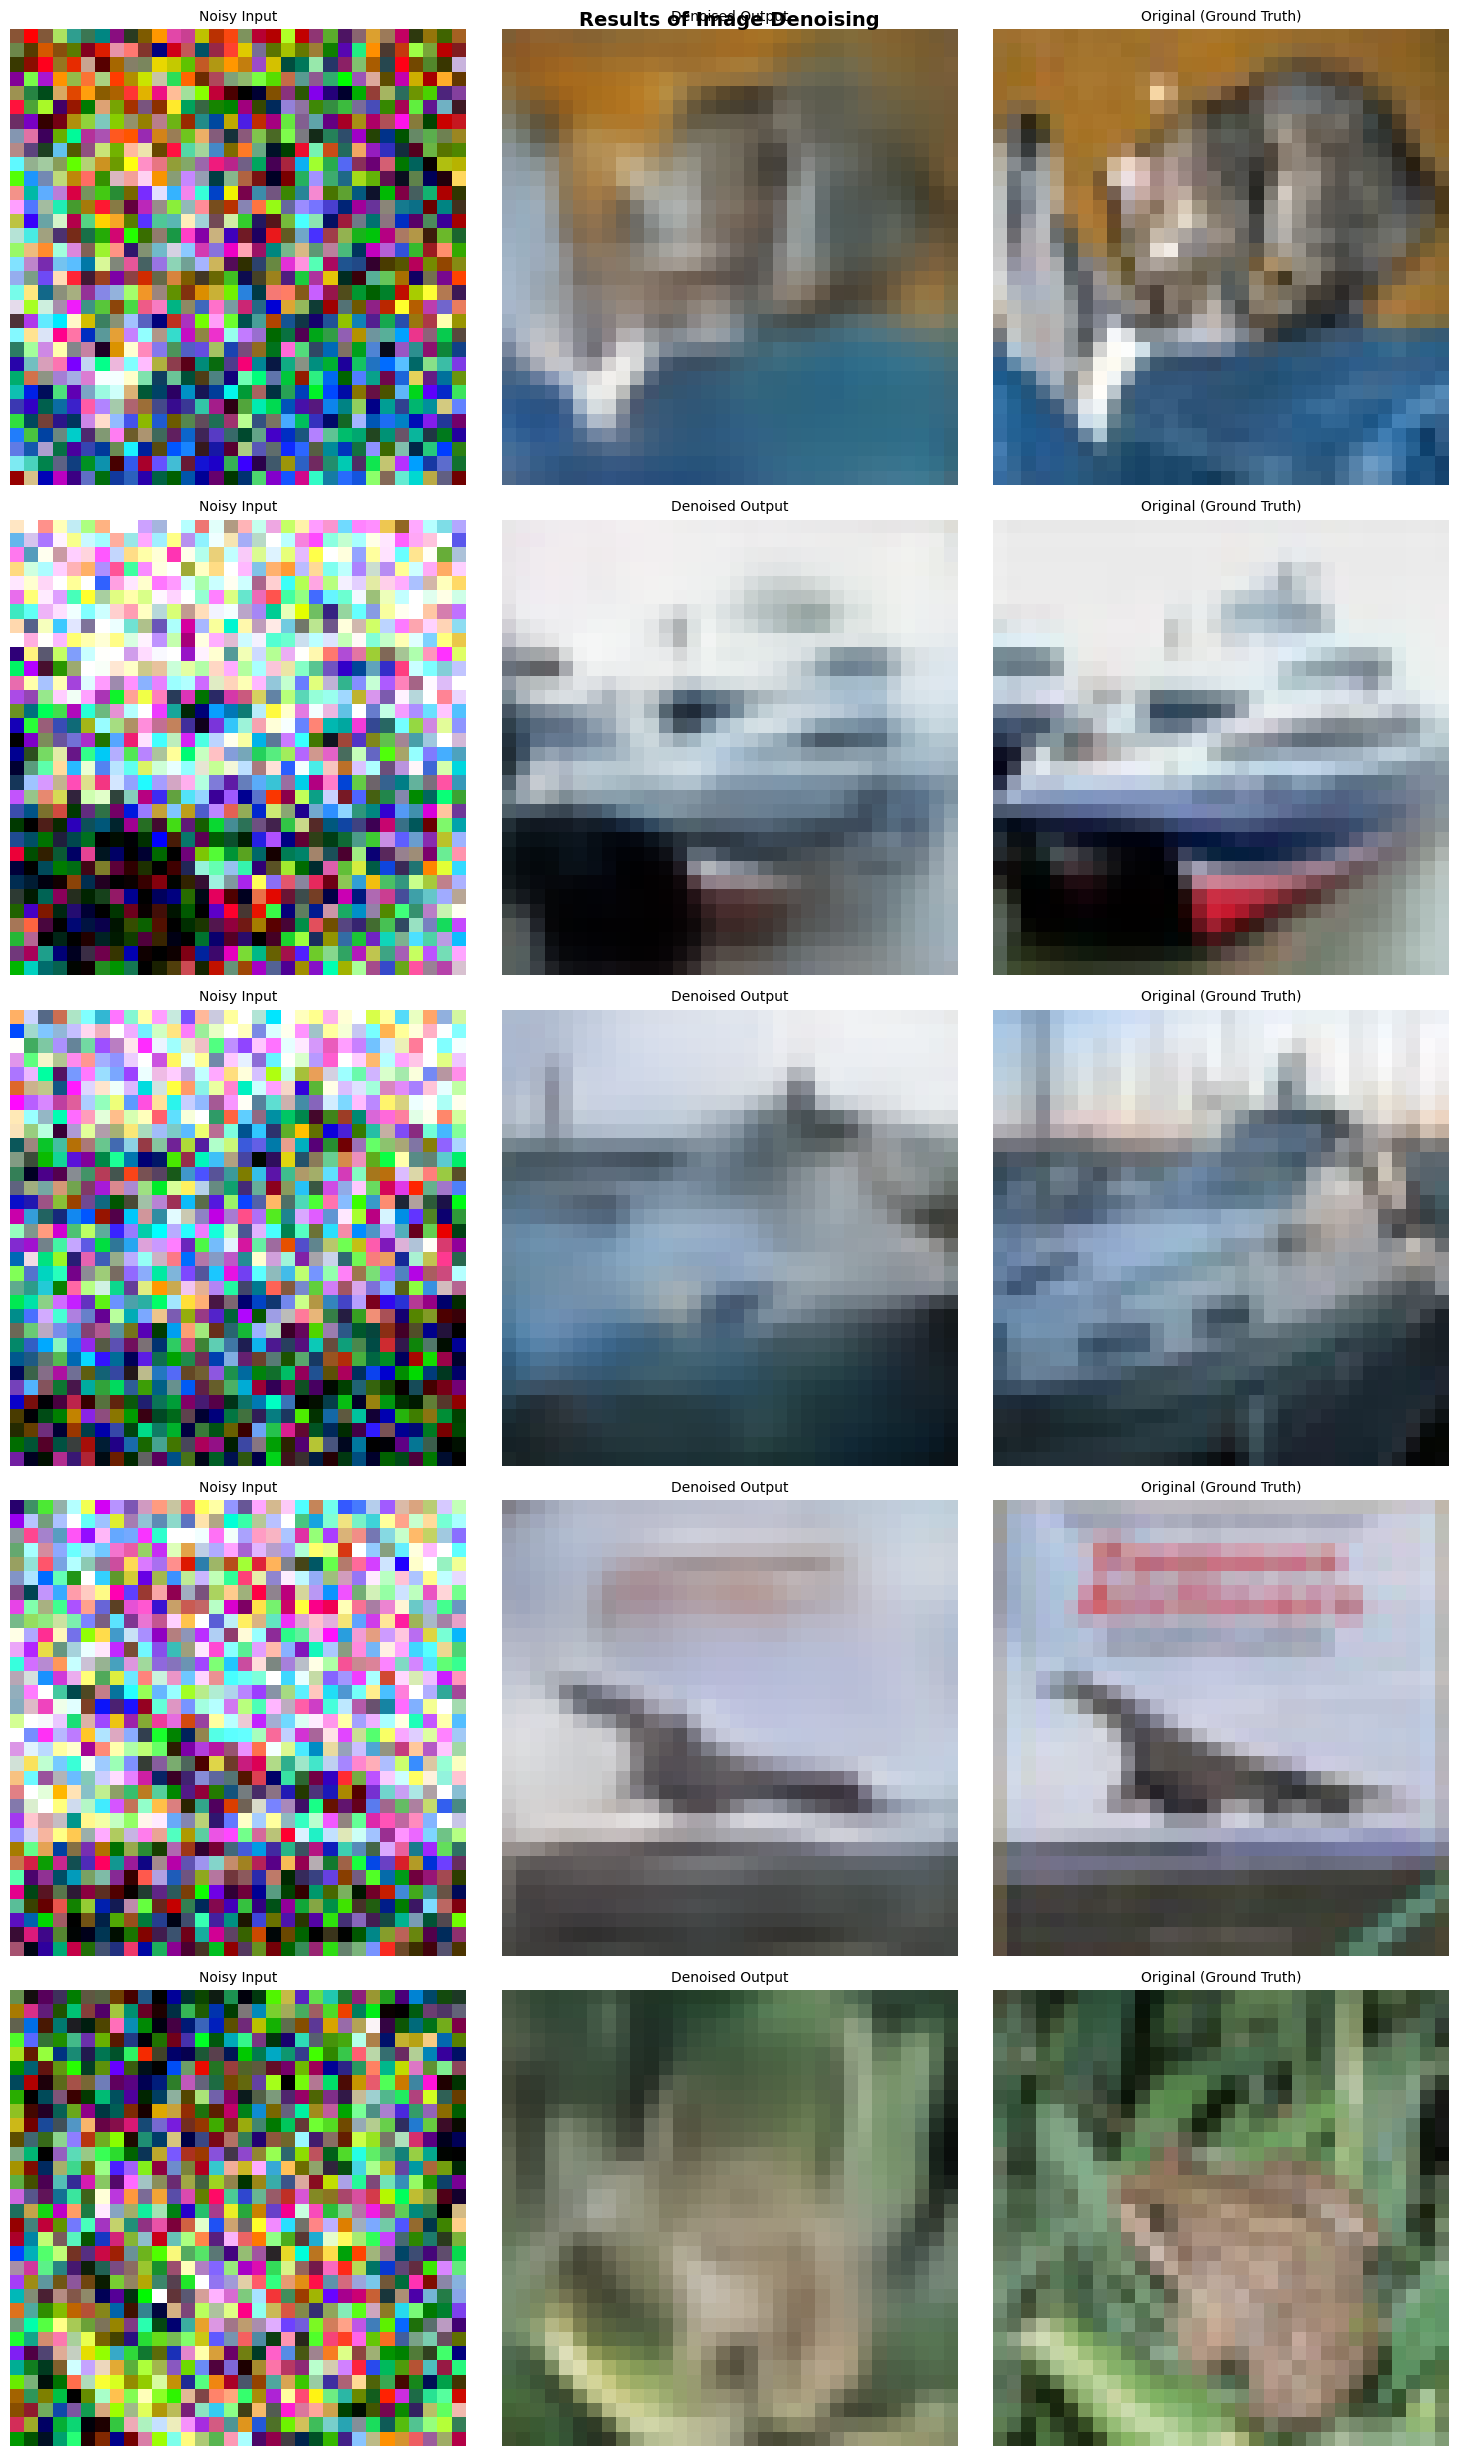

In [ ]:
def visualize_denoising(model, noisy_images, original_images, n_samples=5):
    """Визуализация результатов удаления шума"""

    denoised_images = model.predict(noisy_images[:n_samples], verbose=0)

    fig, axes = plt.subplots(n_samples, 3, figsize=(15, 5 * n_samples))

    if n_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(n_samples):
        axes[i, 0].imshow(noisy_images[i])
        axes[i, 0].set_title('Noisy Input', fontsize=10)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(denoised_images[i])
        axes[i, 1].set_title('Denoised Output', fontsize=10)
        axes[i, 1].axis('off')

        axes[i, 2].imshow(original_images[i])
        axes[i, 2].set_title('Original (Ground Truth)', fontsize=10)
        axes[i, 2].axis('off')

    plt.suptitle('Results of Image Denoising', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_denoising(model_denoising, X_test_noisy, testX_denoise, n_samples=5)

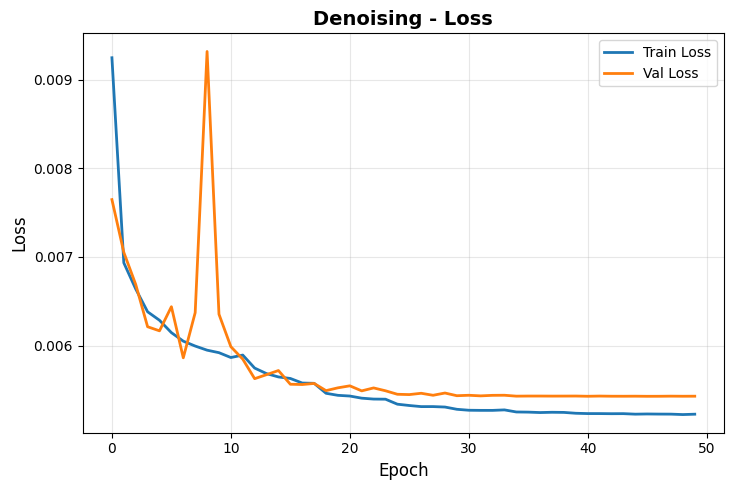

Final Train Loss: 0.0052
Final Val Loss: 0.0054


In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_denoise.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history_denoise.history['val_loss'], label='Val Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Denoising - Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final Train Loss: {history_denoise.history["loss"][-1]:.4f}')
print(f'Final Val Loss: {history_denoise.history["val_loss"][-1]:.4f}')

## **Задание №.3 Реализуйте автоэнкодер для улучшения качества изображения путём увеличения его разрешения (апскейлинг-[определение](https://dic.academic.ru/dic.nsf/ruwiki/346555))**



1. На входной слой нейронной сети подаётся изображение с размерностью (256, 256,3) - X_test. В результате работы нейронной сети на выходном слое должно получиться изображение (512, 512, 3) - Y_test. В итоге мы получаем двукратный апскейл исходного изображения.

2. Датасет собираете из изображений, разрешение которых выше эталонного (512,512,3). Затем преобразуете их в указанные размерности и формируете из них обучающую и проверочную выборку.

3. Обучите модель. Отобразите графики обучения

4. Подумайте, каким образом можно будет адаптировать модель вашей нейронной сети для двухратного апскейла изображения с любой размерностью, большей, чем (256,256,3), с полным или частичным сохранением его исходных пропорций. Например: подаём на вход изображение с разрешением (1920, 1080, 3) - получаем изображение с разрешением (3840, 2160, 3), т.е. с полным сохранением исходных пропорций или (1792, 1024, 3) с частичным сохранением исходных пропорций.

> Подсказка: Для этого можно реализовать алгоритм предварительной обработки исходного изображения, перед подачей его в нейронную сеть

In [ ]:
print('Подготовка данных для апскейлинга...')

# Используем CIFAR-100 и создаем пары low-res / high-res
# Low-res: 32x32, High-res: 64x64 (2x upscale для демонстрации)

from keras.preprocessing.image import img_to_array, load_img, array_to_img

def create_upscale_dataset(images, scale_factor=2):
    """Создание пар изображений для апскейлинга"""

    low_res_images = []
    high_res_images = []

    original_size = images.shape[1]
    target_size = original_size * scale_factor

    for img in images:
        # High-res - оригинальное изображение (ресайзим до target_size)
        img_high = cv2.resize(img, (target_size, target_size), interpolation=cv2.INTER_CUBIC)

        # Low-res - уменьшенная версия
        img_low = cv2.resize(img, (original_size, original_size), interpolation=cv2.INTER_AREA)

        high_res_images.append(img_high)
        low_res_images.append(img_low)

    return np.array(low_res_images), np.array(high_res_images)

X_low, X_high = create_upscale_dataset(trainX[:10000], scale_factor=2)
X_low_test, X_high_test = create_upscale_dataset(testX[:2000], scale_factor=2)

print(f'Low-res train: {X_low.shape}')
print(f'High-res train: {X_high.shape}')
print(f'Low-res test: {X_low_test.shape}')
print(f'High-res test: {X_high_test.shape}')

Подготовка данных для апскейлинга...
Low-res train: (10000, 32, 32, 3)
High-res train: (10000, 64, 64, 3)
Low-res test: (2000, 32, 32, 3)
High-res test: (2000, 64, 64, 3)


In [ ]:
def create_super_resolution_autoencoder(input_shape=(32, 32, 3), output_shape=(64, 64, 3)):
    """
    Автоэнкодер для апскейлинга изображений

    Args:
        input_shape: размерность входного изображения
        output_shape: размерность выходного изображения
    """
    inputs = Input(shape=input_shape)

    # Encoder
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    # Decoder с Upsampling
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    # Upscaling блок (один раз для 2x увеличения)
    x = Conv2DTranspose(128, (3, 3), strides=(2, 2), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)

    outputs = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    model = Model(inputs, outputs)
    return model

# Создание модели с правильными размерностями
model_upscale = create_super_resolution_autoencoder(input_shape=(32, 32, 3), output_shape=(64, 64, 3))
model_upscale.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 64, 64, 128)    │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,077,315 (4.11 MB)

 Trainable params: 1,075,395 (4.10 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
model_upscale.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

callbacks_upscale = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath='models/autoencoders/upscale_best.h5',
                    monitor='val_loss', save_best_only=True, mode='min', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    CSVLogger('models/autoencoders/upscale_history.csv', append=False),
    TensorBoard(log_dir='logs/autoencoders/upscale', histogram_freq=1)
]

print('Обучение модели апскейлинга...')
history_upscale = model_upscale.fit(
    X_low, X_high,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks_upscale,
    verbose=1
)

Обучение модели апскейлинга...
Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0110 - mae: 0.0666
Epoch 1: val_loss improved from None to 0.03166, saving model to models/autoencoders/upscale_best.h5



Epoch 1: finished saving model to models/autoencoders/upscale_best.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 51s 120ms/step - loss: 0.0048 - mae: 0.0483 - val_loss: 0.0317 - val_mae: 0.1467 - learning_rate: 0.0010
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0024 - mae: 0.0378
Epoch 2: val_loss improved from 0.03166 to 0.00436, saving model to models/autoencoders/upscale_best.h5



Epoch 2: finished saving model to models/autoencoders/upscale_best.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - loss: 0.0023 - mae: 0.0372 - val_loss: 0.0044 - val_mae: 0.0503 - learning_rate: 0.0010
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.0020 - mae: 0.0348
Epoch 3: val_loss improved from 0.00436 to 0.00188, saving model to models/autoencoders/upscale_best.h5



Epoch 3: finished saving model to models/autoencoders/upscale_best.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 100ms/step - loss: 0.0019 - mae: 0.0340 - val_loss: 0.0019 - val_mae: 0.0339 - learning_rate: 0.0010
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0017 - mae: 0.0319
Epoch 4: val_loss improved from 0.00188 to 0.00179, saving model to models/autoencoders/upscale_best.h5



Epoch 4: finished saving model to models/autoencoders/upscale_best.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - loss: 0.0017 - mae: 0.0318 - val_loss: 0.0018 - val_mae: 0.0324 - learning_rate: 0.0010
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0018 - mae: 0.0327
Epoch 5: val_loss did not improve from 0.00179
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 96ms/step - loss: 0.0016 - mae: 0.0313 - val_loss: 0.0037 - val_mae: 0.0504 - learning_rate: 0.0010
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0016 - mae: 0.0311
Epoch 6: val_loss improved from 0.00179 to 0.00167, saving model to models/autoencoders/upscale_best.h5


...


Epoch 37: finished saving model to models/autoencoders/upscale_best.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - loss: 1.9718e-04 - mae: 0.0106 - val_loss: 1.0342e-04 - val_mae: 0.0078 - learning_rate: 6.2500e-05
Epoch 38/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 1.9261e-04 - mae: 0.0106
Epoch 38: val_loss did not improve from 0.00010
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 96ms/step - loss: 2.0416e-04 - mae: 0.0107 - val_loss: 1.0636e-04 - val_mae: 0.0077 - learning_rate: 6.2500e-05
Epoch 39/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 2.0309e-04 - mae: 0.0108
Epoch 39: val_loss did not improve from 0.00010
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 96ms/step - loss: 1.9567e-04 - mae: 0.0106 - val_loss: 1.2414e-04 - val_mae: 0.0089 - learning_rate: 6.2500e-05
Epoch 40/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 2.0073e-04 - mae: 0.0108
Epoch 40: val_loss did not improve from 0.00010
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - loss: 1.9025e-04 - mae: 0.0105 - val_loss: 


Epoch 41: finished saving model to models/autoencoders/upscale_best.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 98ms/step - loss: 1.8006e-04 - mae: 0.0102 - val_loss: 9.3055e-05 - val_mae: 0.0074 - learning_rate: 6.2500e-05
Epoch 42/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 1.9260e-04 - mae: 0.0105
Epoch 42: val_loss did not improve from 0.00009

Epoch 42: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - loss: 1.9099e-04 - mae: 0.0105 - val_loss: 1.1788e-04 - val_mae: 0.0086 - learning_rate: 6.2500e-05
Epoch 43/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 1.7245e-04 - mae: 0.0099
Epoch 43: val_loss did not improve from 0.00009
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 98ms/step - loss: 1.6898e-04 - mae: 0.0098 - val_loss: 9.3287e-05 - val_mae: 0.0075 - learning_rate: 3.1250e-05
Epoch 44/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 1.7791e-04 - mae: 0.0100
Epoch 44: val_loss improved from 0.00009 to 0.00009, savin


Epoch 44: finished saving model to models/autoencoders/upscale_best.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - loss: 1.7159e-04 - mae: 0.0099 - val_loss: 8.9364e-05 - val_mae: 0.0074 - learning_rate: 3.1250e-05
Epoch 45/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 1.7716e-04 - mae: 0.0099
Epoch 45: val_loss improved from 0.00009 to 0.00008, saving model to models/autoencoders/upscale_best.h5



Epoch 45: finished saving model to models/autoencoders/upscale_best.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - loss: 1.7574e-04 - mae: 0.0099 - val_loss: 8.3825e-05 - val_mae: 0.0071 - learning_rate: 3.1250e-05
Epoch 46/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 1.6417e-04 - mae: 0.0096
Epoch 46: val_loss improved from 0.00008 to 0.00008, saving model to models/autoencoders/upscale_best.h5



Epoch 46: finished saving model to models/autoencoders/upscale_best.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - loss: 1.6437e-04 - mae: 0.0096 - val_loss: 8.0322e-05 - val_mae: 0.0068 - learning_rate: 3.1250e-05
Epoch 47/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 1.6536e-04 - mae: 0.0096
Epoch 47: val_loss did not improve from 0.00008

Epoch 47: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - loss: 1.6778e-04 - mae: 0.0097 - val_loss: 1.0348e-04 - val_mae: 0.0080 - learning_rate: 3.1250e-05
Epoch 48/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 1.6074e-04 - mae: 0.0095
Epoch 48: val_loss did not improve from 0.00008
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 97ms/step - loss: 1.5697e-04 - mae: 0.0094 - val_loss: 8.9744e-05 - val_mae: 0.0074 - learning_rate: 1.5625e-05
Epoch 49/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 1.7399e-04 - mae: 0.0099
Epoch 49: val_loss did not improve from 0.00008
250/250 ━

Upscaled min/max: 0.009 / 1.000


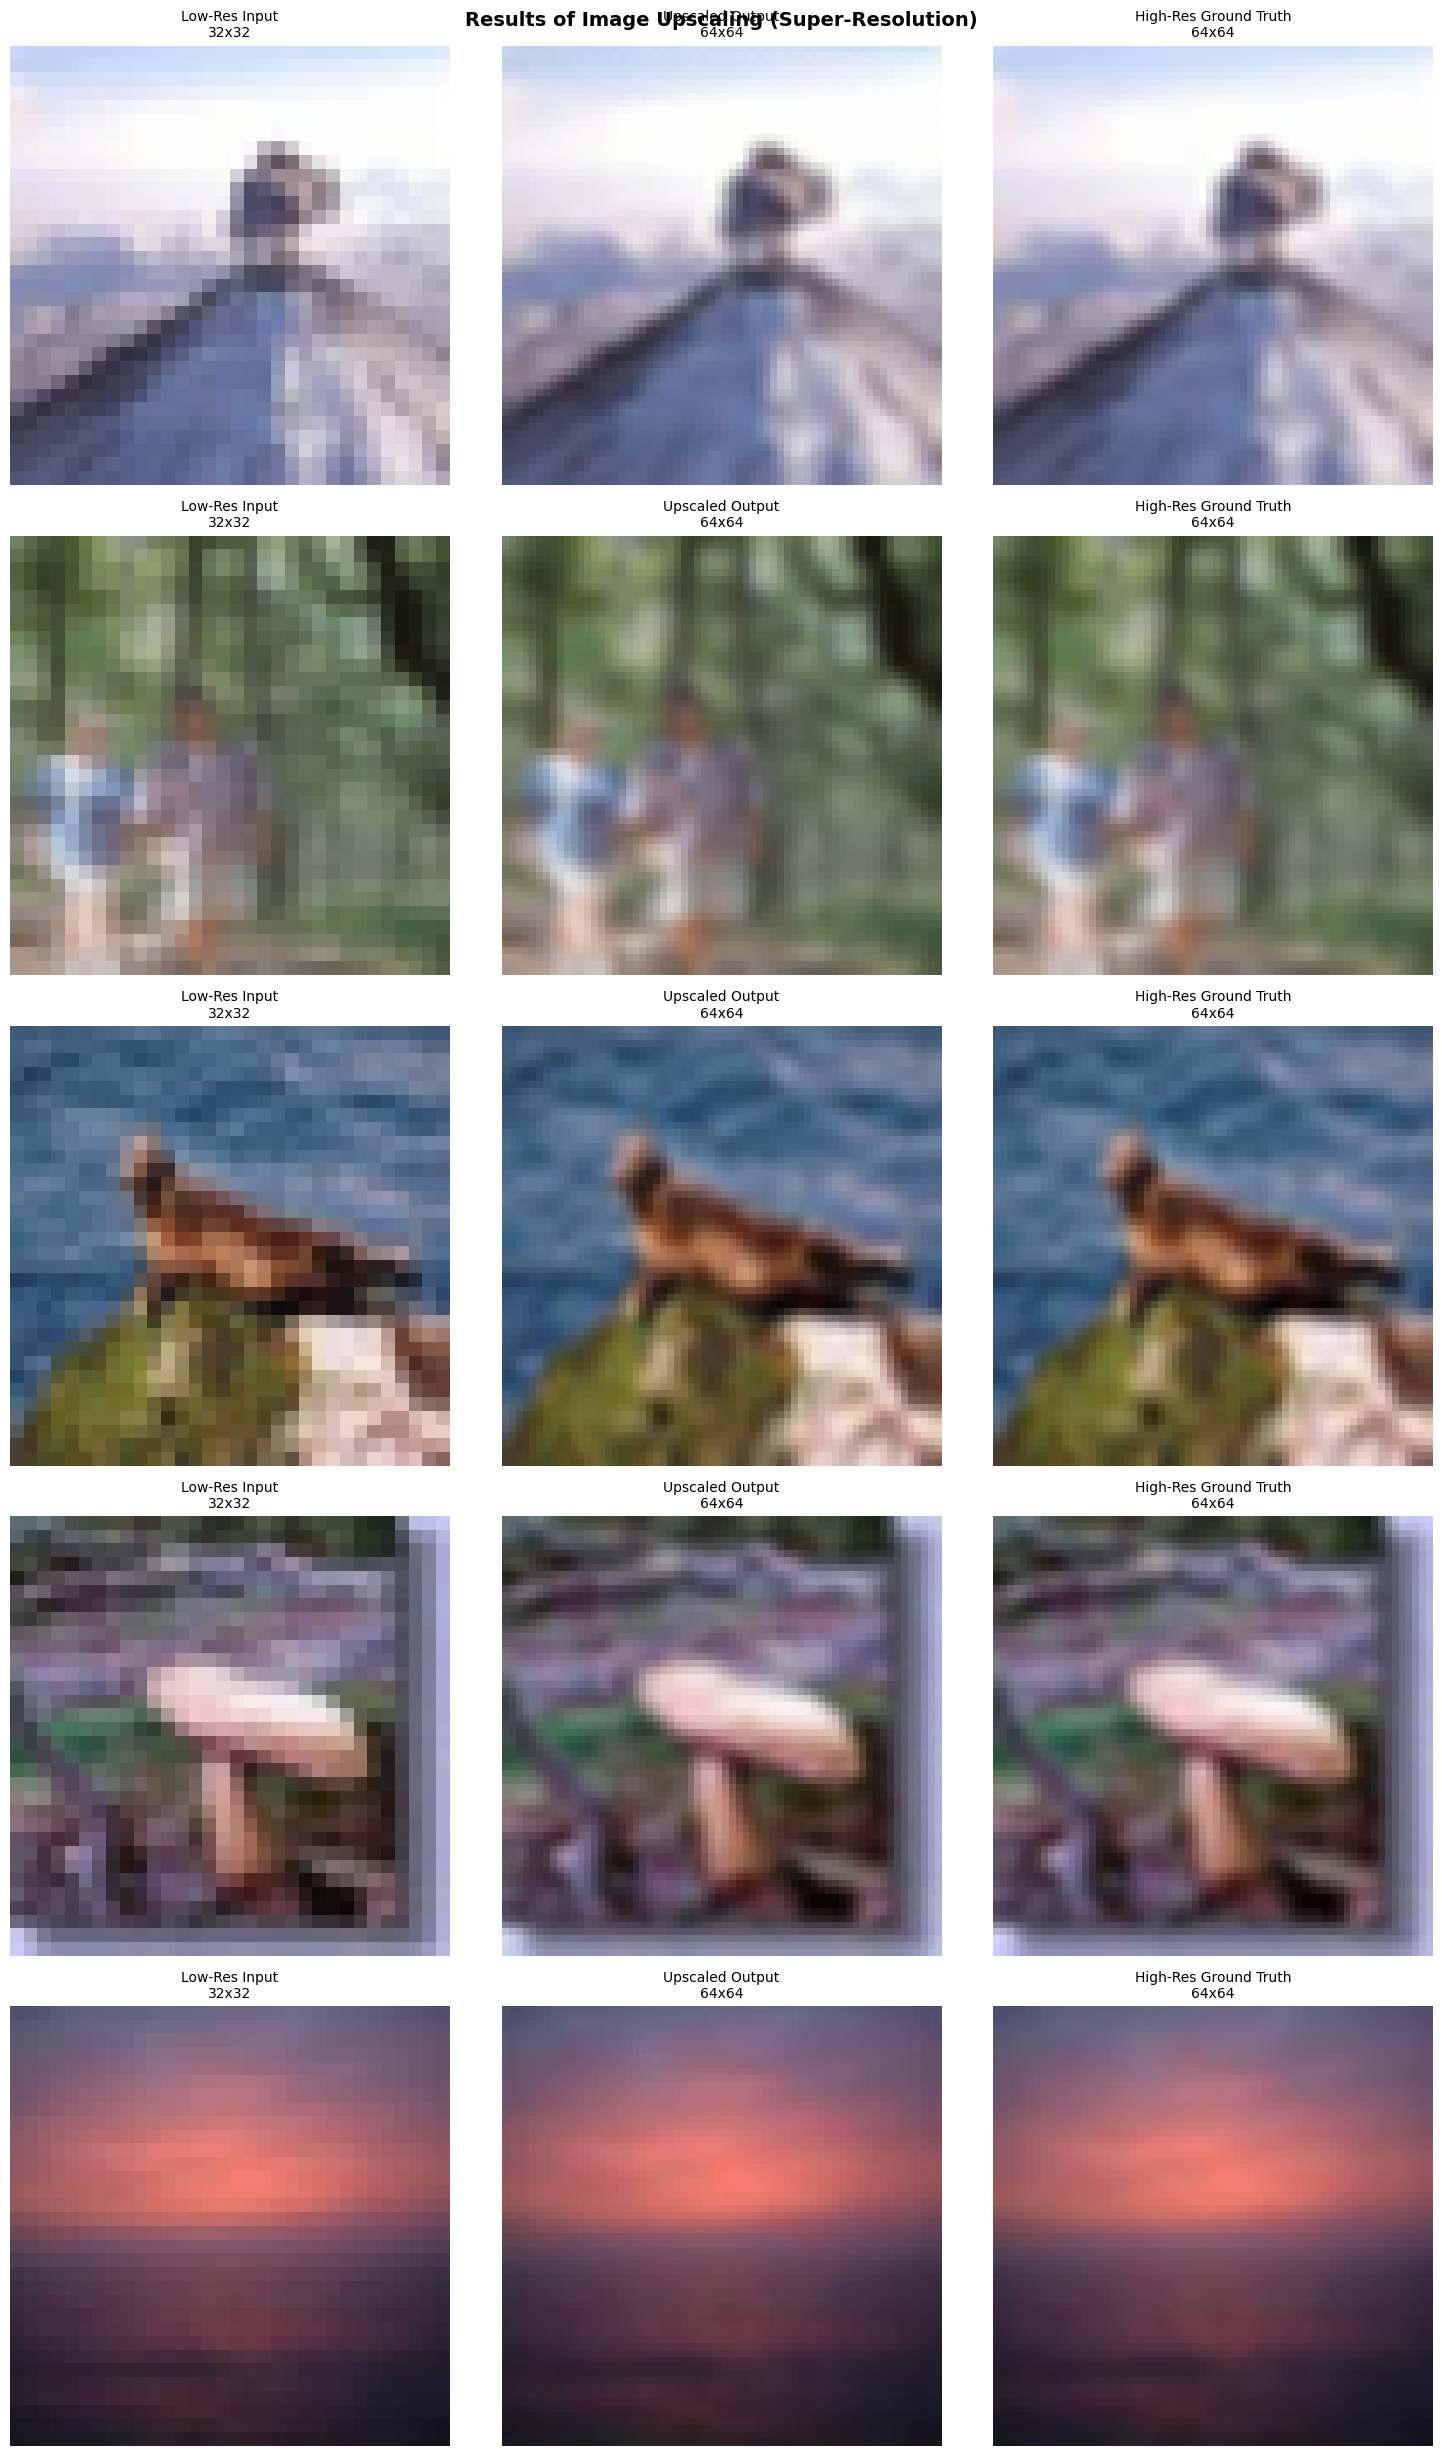

In [ ]:
def visualize_upscaling(model, low_res_images, high_res_images, n_samples=5):
    """Визуализация результатов апскейлинга"""

    upscaled_images = model.predict(low_res_images[:n_samples], verbose=0)

    # Проверка значений
    print(f'Upscaled min/max: {upscaled_images.min():.3f} / {upscaled_images.max():.3f}')

    fig, axes = plt.subplots(n_samples, 3, figsize=(15, 5 * n_samples))

    if n_samples == 1:
        axes = axes.reshape(1, -1)

    for i in range(n_samples):
        axes[i, 0].imshow(low_res_images[i])
        axes[i, 0].set_title(f'Low-Res Input\n{low_res_images[i].shape[0]}x{low_res_images[i].shape[1]}', fontsize=10)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(upscaled_images[i])
        axes[i, 1].set_title(f'Upscaled Output\n{upscaled_images[i].shape[0]}x{upscaled_images[i].shape[1]}', fontsize=10)
        axes[i, 1].axis('off')

        axes[i, 2].imshow(high_res_images[i])
        axes[i, 2].set_title(f'High-Res Ground Truth\n{high_res_images[i].shape[0]}x{high_res_images[i].shape[1]}', fontsize=10)
        axes[i, 2].axis('off')

    plt.suptitle('Results of Image Upscaling (Super-Resolution)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_upscaling(model_upscale, X_low_test, X_high_test, n_samples=5)

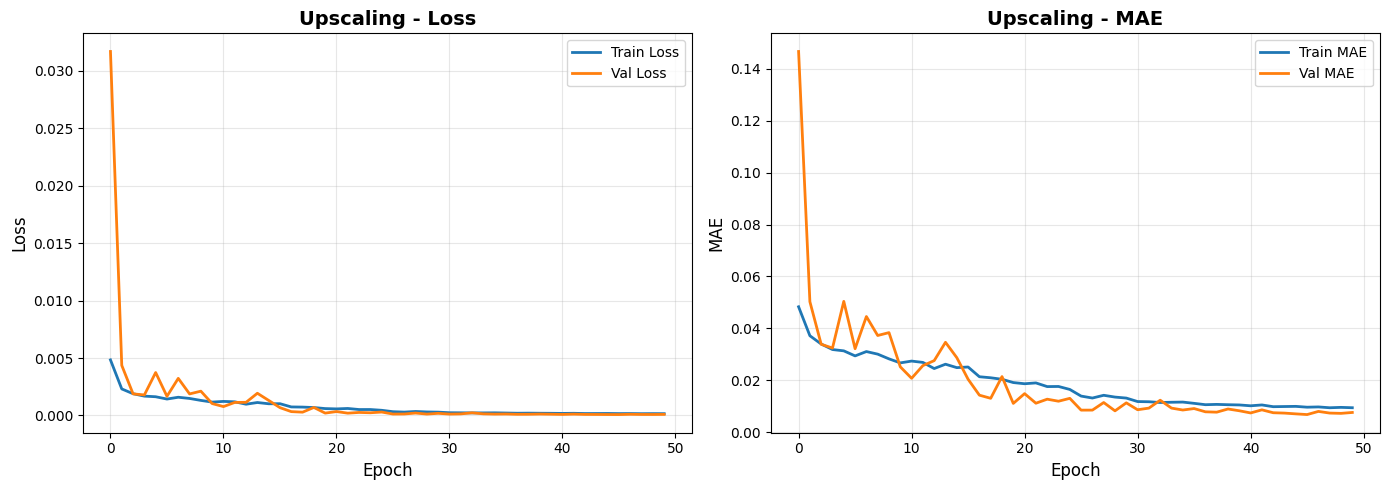

Final Train Loss: 0.0002
Final Val Loss: 0.0001


In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_upscale.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history_upscale.history['val_loss'], label='Val Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Upscaling - Loss', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_upscale.history['mae'], label='Train MAE', linewidth=2)
plt.plot(history_upscale.history['val_mae'], label='Val MAE', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MAE', fontsize=12)
plt.title('Upscaling - MAE', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final Train Loss: {history_upscale.history["loss"][-1]:.4f}')
print(f'Final Val Loss: {history_upscale.history["val_loss"][-1]:.4f}')

In [ ]:
def upscale_image_any_size(model, image, scale_factor=2):
    """
    Апскейлинг изображения с любым разрешением

    Args:
        model: обученная модель
        image: исходное изображение (numpy array)
        scale_factor: коэффициент масштабирования

    Returns:
        upscaled_image: изображение с повышенным разрешением
    """
    import cv2

    # Копируем изображение
    if isinstance(image, str):
        img = cv2.imread(image)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img = image.copy()

    original_shape = img.shape
    original_height, original_width = original_shape[0], original_shape[1]

    # Нормализация [0, 1]
    if img.max() > 1:
        img_normalized = img.astype('float32') / 255.0
    else:
        img_normalized = img.astype('float32')

    # Ресайз до размера входа модели (32x32)
    img_input = cv2.resize(img_normalized, (32, 32), interpolation=cv2.INTER_AREA)
    img_input = np.expand_dims(img_input, axis=0)

    # Предсказание
    upscaled = model.predict(img_input, verbose=0)[0]

    # Клиппинг значений
    upscaled = np.clip(upscaled, 0, 1)

    # Ресайз до целевого размера (оригинал * scale_factor)
    target_width = original_width * scale_factor
    target_height = original_height * scale_factor

    upscaled_final = cv2.resize(upscaled, (target_width, target_height), interpolation=cv2.INTER_CUBIC)
    upscaled_final = np.clip(upscaled_final, 0, 1)

    return upscaled_final

Тестирование апскейлинга...
Тест 1:
  Исходный размер: (32, 32)
  Результат: (64, 64)
  Min/Max: 0.000 / 0.987


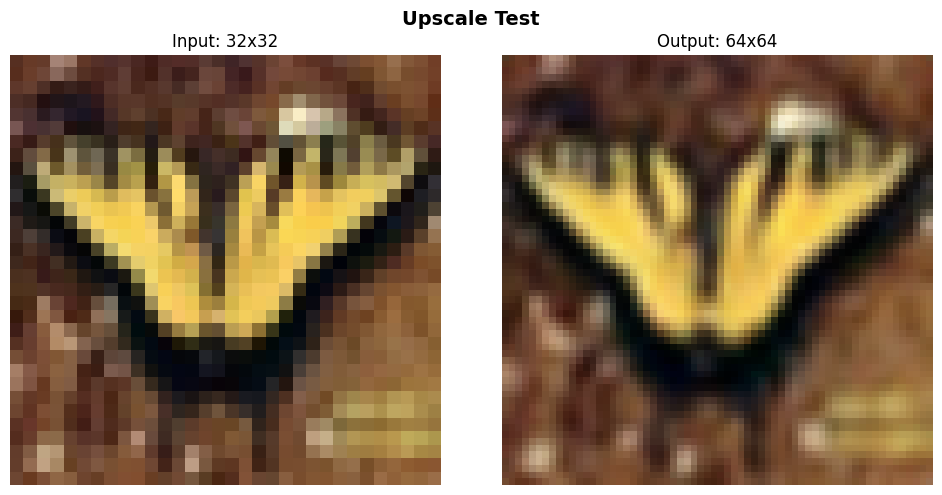

Тест 2:
  Исходный размер: (32, 32)
  Результат: (64, 64)
  Min/Max: 0.001 / 0.995


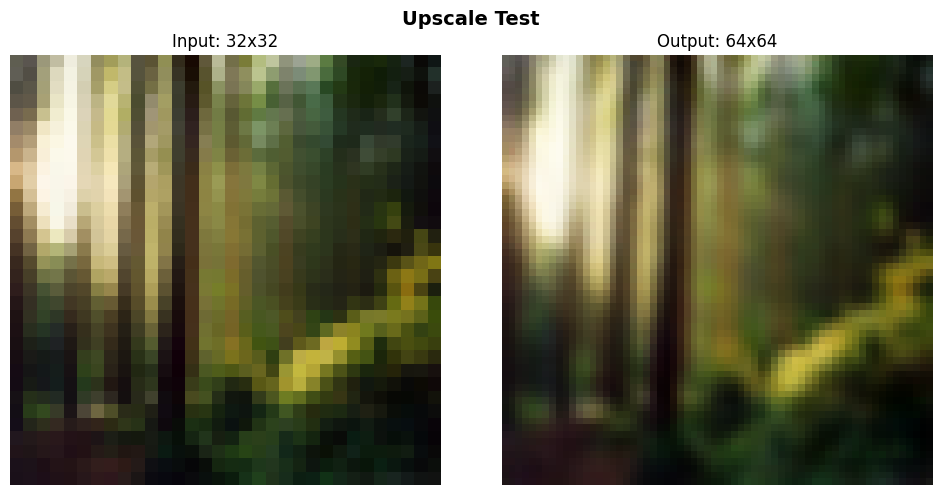

Тест 3:
  Исходный размер: (32, 32)
  Результат: (64, 64)
  Min/Max: 0.000 / 0.993


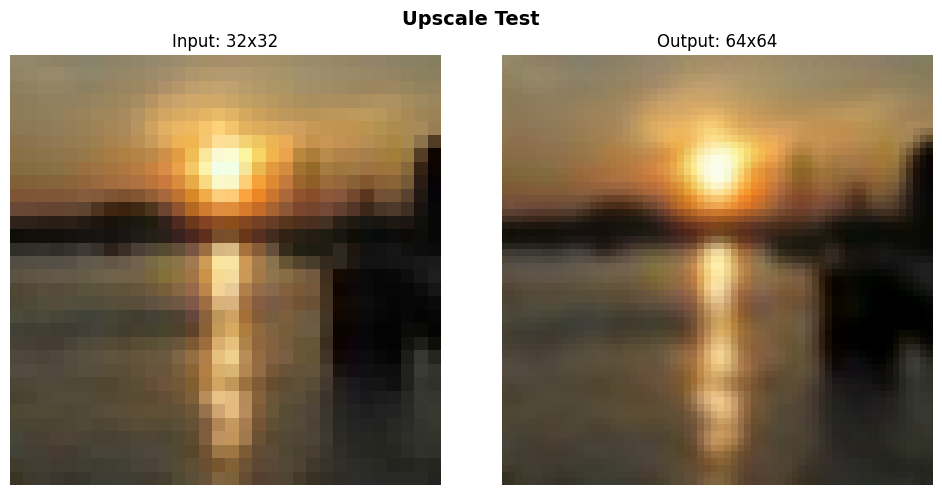

In [ ]:
def test_upscale_function_fixed(model, test_images, scale_factor=2):
    """Тестирование функции апскейлинга"""

    print('Тестирование апскейлинга...')

    # Берем несколько тестовых изображений
    for i in range(3):
        img = test_images[np.random.randint(0, len(test_images))]

        # Апскейлинг (ИСПРАВЛЕНО: scale_factor вместо target_scale)
        upscaled = upscale_image_any_size(model, img, scale_factor=scale_factor)

        print(f'Тест {i+1}:')
        print(f'  Исходный размер: {img.shape[:2]}')
        print(f'  Результат: {upscaled.shape[:2]}')
        print(f'  Min/Max: {upscaled.min():.3f} / {upscaled.max():.3f}')

        # Визуализация
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img)
        axes[0].set_title(f'Input: {img.shape[0]}x{img.shape[1]}', fontsize=12)
        axes[0].axis('off')

        axes[1].imshow(upscaled)
        axes[1].set_title(f'Output: {upscaled.shape[0]}x{upscaled.shape[1]}', fontsize=12)
        axes[1].axis('off')

        plt.suptitle(f'Upscale Test', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

# Запуск тестирования
test_upscale_function_fixed(model_upscale, X_low_test, scale_factor=2)

In [ ]:
print('Сохранение моделей...')

model_colorization.save('models/autoencoders/colorization_model.h5')
model_denoising.save('models/autoencoders/denoising_model.h5')
model_upscale.save('models/autoencoders/upscale_model.h5')

print('Модели сохранены:')
print('  - models/autoencoders/colorization_model.h5')
print('  - models/autoencoders/denoising_model.h5')
print('  - models/autoencoders/upscale_model.h5')

. Автоэнкодер для колоризации:
   - Вход: черно-белое изображение (L канал LAB пространства)
   - Выход: цветные каналы (AB каналы LAB пространства)
   - Применение: реставрация старых фотографий, художественная обработка

2. Автоэнкодер для удаления шума:
   - Вход: зашумленное изображение
   - Выход: очищенное изображение
   - Применение: улучшение качества фотографий, медицинская визуализация

3. Автоэнкодер для апскейлинга:
   - Вход: изображение низкого разрешения
   - Выход: изображение высокого разрешения
   - Применение: улучшение качества видео, увеличение изображений

Общие рекомендации:
- Использовать более глубокие архитектуры для сложных задач
- Применять perceptual loss для лучшего визуального качества
- Использовать данные аугментации для улучшения обобщения
- Рассмотреть использование U-Net архитектуры с skip connections
- Для production использовать предобученные модели (ESRGAN, etc.)